<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>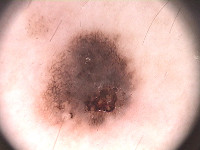</td><td>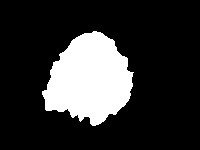</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [156]:
# !gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

In [157]:
# get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [158]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [159]:
from skimage.transform import resize

size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False, order=0, preserve_range=True) > 0.5 for y in lesions]



In [160]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

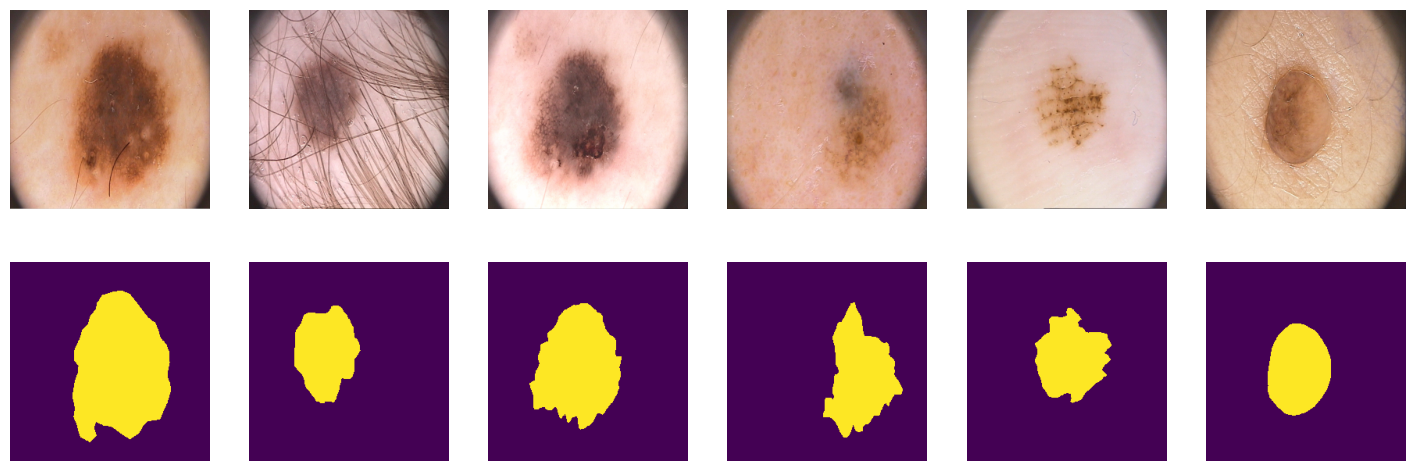

In [161]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на ~~100/50/50~~ 160/20/20 (100 маловато для обучения)
 для обучения, валидации и теста соответственно

In [162]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [160, 180])

In [163]:
print(len(tr), len(val), len(ts))

160 20 20


## PyTorch DataLoader

In [164]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [165]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





![](https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN)

In [166]:
# !pip install torchmetrics

In [167]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(DEVICE)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:** 

По сути, по ссылке https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits уже написан вывод одного из другого, но с другими обозначениями. 

Знак суммы убираем, переписав выражение в векторном виде:

$y \cdot -\log(\sigma(\hat y)) + (1 - y)\cdot -\log(1 - \sigma(\hat y))$

Раскрываем сигмоиду:

$y \cdot -\log\left(\frac{1}{1 + e^{-\hat y}}\right)+ (1 - y)\cdot -\log\left(\frac{e^{-\hat y}}{1 + e^{-\hat y}}\right)$

Играем со свойствами логарифма и избавляемся от дробей и минусов:

$y \cdot \log(1 + e^{-\hat y})+ (1 - y)\cdot\left(-\log(e^{-\hat y}) + \log(1 + e^{-\hat y})\right)$

Раскрываем тривиальный логарифм от экспоненты:

$y \cdot \log(1 + e^{-\hat y})+ (1 - y)\cdot\left(\hat y + \log(1 + e^{-\hat y})\right)$

Раскрываем скобки и сокращаем множитель у логарифмов, остается 1 штука логарифма:

$(1 - y)\hat y + \log(1 + e^{-\hat y})$

И еще раз раскрываем скобки:

$\hat y - \hat y y + \log(1 + e^{-\hat y})$

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [168]:
import torch.nn.functional as F
import torch.nn as nn

In [169]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

Еще раз формулы, чтобы глазами не бегать выше:

$y \cdot -\log(\sigma(\hat y)) + (1 - y)\cdot -\log(1 - \sigma(\hat y))$

$(1 - y)\hat y + \log(1 + e^{-\hat y})$

In [170]:
def bce_loss(y_pred, y_real):
    eps = 1e-12
    y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()

def bce_true(y_pred, y_real):
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()

Проверим корректность работы на простом примере

In [171]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный      = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch            = 4.6905107498168945
BCE loss честно посчитанный      = 4.6905107498168945
BCE loss from torch              = 4.6905107498168945
BCE loss from torch with logits  = 4.6905107498168945


C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [172]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [173]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 17.508941650390625
BCE loss честно посчитанный               = 17.508941650390625
BCE loss from torch bce_torch             = 17.508941650390625
BCE loss from torch with logits bce_torch = 17.508941650390625


C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


In [174]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Давайте посчитаем на реальных логитах и сегментационной маске:

In [175]:
# !gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

In [176]:
path_to_dummy_samples = './for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(DEVICE)
dummpy_sample['logits'] = dummpy_sample['logits'].to(DEVICE)

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\3484867643.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dummpy_sample = {'logits': torch.load(f'{path_to_dum

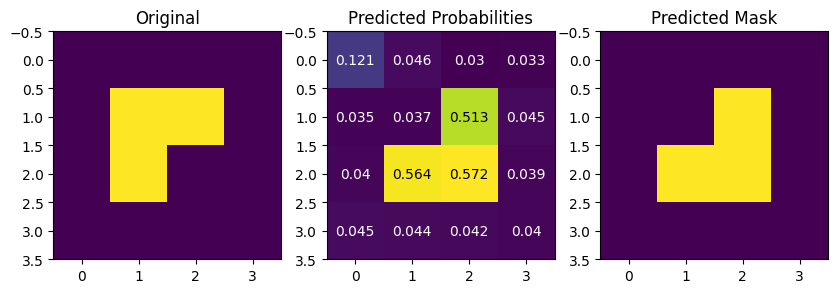

In [177]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [178]:
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

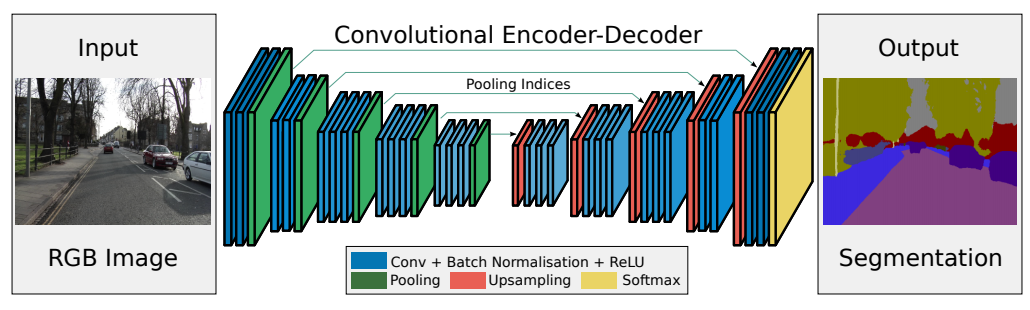

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [179]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [180]:
# model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

In [181]:
# model_vgg16

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [182]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [183]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, tail = False):
        super(DecoderBlock, self).__init__() 
        
        self.upsampling = nn.MaxUnpool2d(kernel_size=2, stride=2)
        
        self.layers = nn.ModuleList()

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = in_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))

        if not tail:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))
        else:
            pass  # в хвосте нет активации 


    def forward(self, x, max_indices):
        x = self.upsampling(x, max_indices)
        
        for layer in self.layers:
            x = layer(x)
        
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [184]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        self.encoders = nn.ModuleList([
            EncoderBlock(in_channels, num_features, depth=2),
            EncoderBlock(num_features, num_features * 2, depth=2),
            EncoderBlock(num_features * 2, num_features * 4, depth=3),
            EncoderBlock(num_features * 4, num_features * 8, depth=3),
            EncoderBlock(num_features * 8, num_features * 8, depth=3) # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        ])

        self.decoders = nn.ModuleList([
            DecoderBlock(num_features * 8, num_features * 8, depth=3), # Decoder bottleneck
            DecoderBlock(num_features * 8, num_features * 4, depth=3),
            DecoderBlock(num_features * 4, num_features * 2, depth=3),
            DecoderBlock(num_features * 2, num_features, depth=2),
            DecoderBlock(num_features, out_channels, depth=2, tail=True)
        ])


    def forward(self, x):
        max_pooling_indices = []
        for encoder in self.encoders:
            x, indices = encoder(x)
            max_pooling_indices.append(indices)

        for decoder, indices in zip(self.decoders, reversed(max_pooling_indices)):
            x = decoder(x, indices)

        return x  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [185]:
from tqdm.notebook import tqdm

In [186]:
NUM_WORKERS = 1

In [233]:
def fit_epoch(model, train_loader, criterion, optimizer):
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0
    
    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += labels.numel()
        processed_batches += 1

        print("labels dtype/min/max/unique_ratio:",
        labels.dtype, labels.min().item(), labels.max().item(),
        (labels>0).float().mean().item())   # доля положительных
        logits = model(inputs)
        probs = torch.sigmoid(logits)
        print("logits mean/std, probs mean:", logits.mean().item(), logits.std().item(), probs.mean().item())

    train_loss = running_loss / processed_batches
    train_acc = running_corrects.cpu().numpy() / processed_pixels
    return train_loss, train_acc

In [188]:
def eval_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.no_grad():
            logits = model(inputs)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += labels.numel()
        processed_batches += 1

    val_loss = running_loss / processed_batches
    val_acc = running_corrects.double() / processed_pixels
    return val_loss, val_acc

In [189]:
def train(train_dataset, val_dataset, model, epochs, batch_size, criterion, optimizer=None, cb_checkpoint=None, model_name='model'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    history = []
    log_template = "\nEpoch {ep:03d}  |  Loss T:{t_loss:0.4f} \
V:{v_loss:0.4f}  |  Accuracy T:{t_acc:0.4f}, V:{v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        if optimizer is None:
            optimizer = torch.optim.Adam(model.parameters())
        else:
            pass 

        best_val_loss = 999999.9
        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_loss': val_loss, 
                    'val_acc': val_acc, 
                }, f"best_{model_name}.pth")

            if (epoch + 1) % 16 == 0:
                if cb_checkpoint is not None:
                    cb_checkpoint(history)
                
                torch.save({
                    'epoch': epoch,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_acc': val_acc, 
                }, f"checkpoint_{epoch}_{model_name}.pth")

    return history

In [190]:
def plot_epoch_loss(history):
    loss, acc, val_loss, val_acc = zip(*history)

    plt.figure(figsize=(7, 4))
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.legend(loc='best')
    plt.xlabel("epochs")
    plt.ylabel("loss")
    # plt.ylim(0, 1) 
    plt.show()

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [191]:
from torch.utils.data import TensorDataset

def to_tensor_dataset(x, y):
    x_np = np.rollaxis(x, 3, 1).astype(np.float32)   # (N, C, H, W)
    y_np = y[:, np.newaxis].astype(np.float32)       # (N, 1, H, W) 

    X_t = torch.from_numpy(x_np)
    Y_t = torch.from_numpy(y_np)

    return TensorDataset(X_t, Y_t)

train_dataset = to_tensor_dataset(X[tr], Y[tr])
val_dataset = to_tensor_dataset(X[val], Y[val])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)

In [192]:
# Если при обучении падает по out of memory, то память сама не чистится без перезапуска ядра
# так что тут ручная зачистка для повторных запусков
import gc

if 'model' in globals(): 
    del model
if 'dice_model' in globals():
    del dice_model
if 'focal_model' in globals():
    del focal_model
gc.collect()
    
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.5656 V:0.6264  |  Accuracy T:0.7198, V:0.6721

Epoch 002  |  Loss T:0.6223 V:0.5837  |  Accuracy T:0.6837, V:0.6722

Epoch 003  |  Loss T:0.6122 V:0.6338  |  Accuracy T:0.6852, V:0.6721

Epoch 004  |  Loss T:0.6055 V:0.5838  |  Accuracy T:0.6960, V:0.6721

Epoch 005  |  Loss T:0.5313 V:0.4597  |  Accuracy T:0.7555, V:0.8034

Epoch 006  |  Loss T:0.4123 V:0.4082  |  Accuracy T:0.8367, V:0.8386

Epoch 007  |  Loss T:0.3645 V:0.2274  |  Accuracy T:0.8593, V:0.9023

Epoch 008  |  Loss T:0.3467 V:0.2961  |  Accuracy T:0.8577, V:0.8679

Epoch 009  |  Loss T:0.3474 V:0.2884  |  Accuracy T:0.8739, V:0.9054

Epoch 010  |  Loss T:0.3225 V:0.2764  |  Accuracy T:0.8826, V:0.8901

Epoch 011  |  Loss T:0.3362 V:0.3476  |  Accuracy T:0.8730, V:0.8553

Epoch 012  |  Loss T:0.3299 V:0.2230  |  Accuracy T:0.8752, V:0.9011

Epoch 013  |  Loss T:0.2588 V:0.1971  |  Accuracy T:0.8983, V:0.9122

Epoch 014  |  Loss T:0.2586 V:0.2140  |  Accuracy T:0.8989, V:0.9092

Epoch 015  |  Loss 

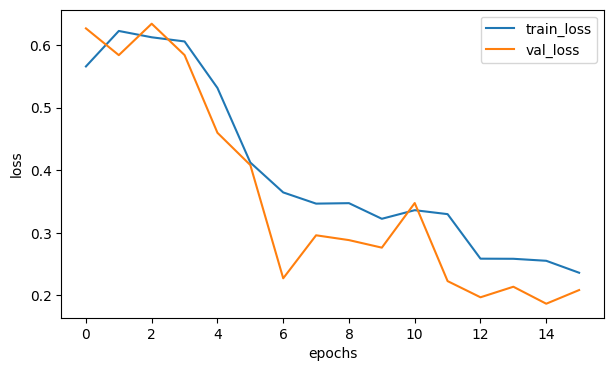


Epoch 017  |  Loss T:0.2424 V:0.1710  |  Accuracy T:0.9044, V:0.9201

Epoch 018  |  Loss T:0.2246 V:0.1657  |  Accuracy T:0.9099, V:0.9234

Epoch 019  |  Loss T:0.2281 V:0.2305  |  Accuracy T:0.9153, V:0.9014

Epoch 020  |  Loss T:0.2374 V:0.1904  |  Accuracy T:0.9095, V:0.9129

Epoch 021  |  Loss T:0.2537 V:0.2333  |  Accuracy T:0.9010, V:0.9034

Epoch 022  |  Loss T:0.2346 V:0.1877  |  Accuracy T:0.9097, V:0.9233

Epoch 023  |  Loss T:0.2240 V:0.1777  |  Accuracy T:0.9107, V:0.9264

Epoch 024  |  Loss T:0.2195 V:0.1721  |  Accuracy T:0.9152, V:0.9259

Epoch 025  |  Loss T:0.2064 V:0.2090  |  Accuracy T:0.9226, V:0.9110

Epoch 026  |  Loss T:0.1941 V:0.1554  |  Accuracy T:0.9241, V:0.9332

Epoch 027  |  Loss T:0.2143 V:0.1422  |  Accuracy T:0.9198, V:0.9343

Epoch 028  |  Loss T:0.2209 V:0.1793  |  Accuracy T:0.9149, V:0.9275

Epoch 029  |  Loss T:0.2030 V:0.1437  |  Accuracy T:0.9229, V:0.9348

Epoch 030  |  Loss T:0.1881 V:0.1641  |  Accuracy T:0.9279, V:0.9244

Epoch 031  |  Loss 

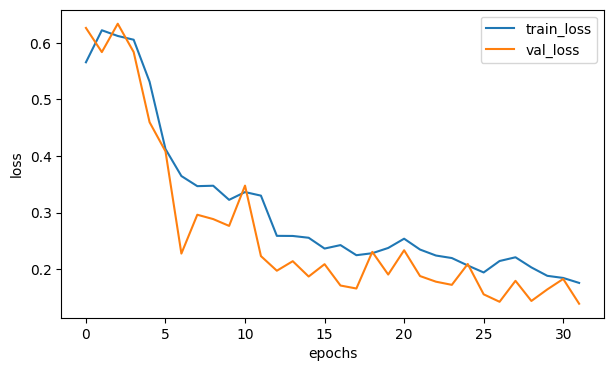


Epoch 033  |  Loss T:0.1560 V:0.1350  |  Accuracy T:0.9371, V:0.9373

Epoch 034  |  Loss T:0.1498 V:0.1539  |  Accuracy T:0.9414, V:0.9272

Epoch 035  |  Loss T:0.1723 V:0.1434  |  Accuracy T:0.9318, V:0.9384

Epoch 036  |  Loss T:0.1448 V:0.1432  |  Accuracy T:0.9434, V:0.9353

Epoch 037  |  Loss T:0.1540 V:0.1328  |  Accuracy T:0.9377, V:0.9376

Epoch 038  |  Loss T:0.1367 V:0.1481  |  Accuracy T:0.9433, V:0.9421

Epoch 039  |  Loss T:0.1427 V:0.1365  |  Accuracy T:0.9426, V:0.9391

Epoch 040  |  Loss T:0.1252 V:0.1300  |  Accuracy T:0.9488, V:0.9427

Epoch 041  |  Loss T:0.1149 V:0.1742  |  Accuracy T:0.9531, V:0.9257

Epoch 042  |  Loss T:0.1164 V:0.1438  |  Accuracy T:0.9520, V:0.9377

Epoch 043  |  Loss T:0.1091 V:0.1316  |  Accuracy T:0.9552, V:0.9422

Epoch 044  |  Loss T:0.1030 V:0.1510  |  Accuracy T:0.9570, V:0.9315

Epoch 045  |  Loss T:0.0986 V:0.1674  |  Accuracy T:0.9589, V:0.9327

Epoch 046  |  Loss T:0.0961 V:0.1317  |  Accuracy T:0.9598, V:0.9439

Epoch 047  |  Loss 

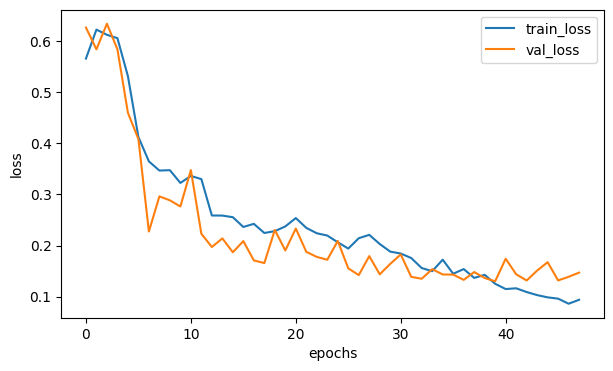


Epoch 049  |  Loss T:0.1098 V:0.1776  |  Accuracy T:0.9552, V:0.9229

Epoch 050  |  Loss T:0.1151 V:0.1839  |  Accuracy T:0.9513, V:0.9321

Epoch 051  |  Loss T:0.1014 V:0.1263  |  Accuracy T:0.9602, V:0.9448

Epoch 052  |  Loss T:0.0907 V:0.1370  |  Accuracy T:0.9616, V:0.9469

Epoch 053  |  Loss T:0.0791 V:0.1322  |  Accuracy T:0.9683, V:0.9457

Epoch 054  |  Loss T:0.0710 V:0.1332  |  Accuracy T:0.9706, V:0.9480

Epoch 055  |  Loss T:0.0688 V:0.1493  |  Accuracy T:0.9710, V:0.9427

Epoch 056  |  Loss T:0.0797 V:0.1193  |  Accuracy T:0.9669, V:0.9441

Epoch 057  |  Loss T:0.0886 V:0.1477  |  Accuracy T:0.9649, V:0.9441

Epoch 058  |  Loss T:0.0718 V:0.1319  |  Accuracy T:0.9704, V:0.9453

Epoch 059  |  Loss T:0.0646 V:0.1276  |  Accuracy T:0.9733, V:0.9500

Epoch 060  |  Loss T:0.0611 V:0.1434  |  Accuracy T:0.9741, V:0.9438

Epoch 061  |  Loss T:0.0523 V:0.1676  |  Accuracy T:0.9780, V:0.9474

Epoch 062  |  Loss T:0.0490 V:0.1727  |  Accuracy T:0.9792, V:0.9439

Epoch 063  |  Loss 

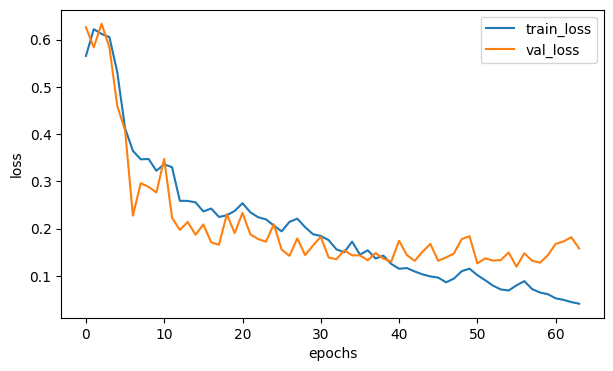


Epoch 065  |  Loss T:0.0389 V:0.1872  |  Accuracy T:0.9835, V:0.9455

Epoch 066  |  Loss T:0.0352 V:0.1977  |  Accuracy T:0.9850, V:0.9465

Epoch 067  |  Loss T:0.0322 V:0.2124  |  Accuracy T:0.9864, V:0.9464

Epoch 068  |  Loss T:0.0298 V:0.2178  |  Accuracy T:0.9873, V:0.9472

Epoch 069  |  Loss T:0.0289 V:0.2535  |  Accuracy T:0.9877, V:0.9444

Epoch 070  |  Loss T:0.0282 V:0.2200  |  Accuracy T:0.9881, V:0.9455

Epoch 071  |  Loss T:0.0272 V:0.2425  |  Accuracy T:0.9884, V:0.9460

Epoch 072  |  Loss T:0.0253 V:0.2149  |  Accuracy T:0.9892, V:0.9475

Epoch 073  |  Loss T:0.0242 V:0.2478  |  Accuracy T:0.9898, V:0.9455

Epoch 074  |  Loss T:0.0242 V:0.2526  |  Accuracy T:0.9898, V:0.9455

Epoch 075  |  Loss T:0.0236 V:0.2858  |  Accuracy T:0.9901, V:0.9432

Epoch 076  |  Loss T:0.0225 V:0.2679  |  Accuracy T:0.9904, V:0.9448

Epoch 077  |  Loss T:0.0215 V:0.2774  |  Accuracy T:0.9908, V:0.9457

Epoch 078  |  Loss T:0.0201 V:0.2922  |  Accuracy T:0.9915, V:0.9439

Epoch 079  |  Loss 

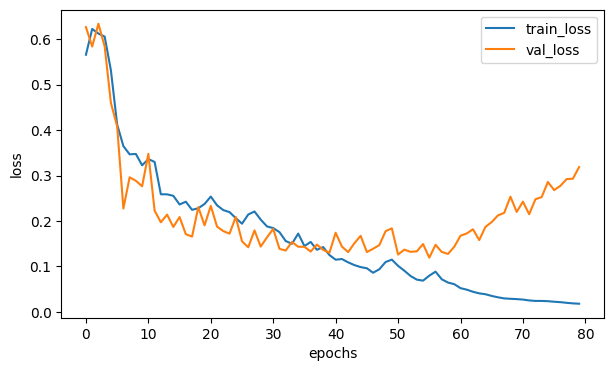


Epoch 081  |  Loss T:0.0168 V:0.3280  |  Accuracy T:0.9929, V:0.9450

Epoch 082  |  Loss T:0.0170 V:0.3145  |  Accuracy T:0.9928, V:0.9462

Epoch 083  |  Loss T:0.0165 V:0.2996  |  Accuracy T:0.9930, V:0.9447

Epoch 084  |  Loss T:0.0163 V:0.3070  |  Accuracy T:0.9930, V:0.9446

Epoch 085  |  Loss T:0.0157 V:0.3332  |  Accuracy T:0.9933, V:0.9441

Epoch 086  |  Loss T:0.0165 V:0.3039  |  Accuracy T:0.9929, V:0.9452

Epoch 087  |  Loss T:0.0160 V:0.3348  |  Accuracy T:0.9932, V:0.9434

Epoch 088  |  Loss T:0.0166 V:0.3245  |  Accuracy T:0.9929, V:0.9430

Epoch 089  |  Loss T:0.0162 V:0.3031  |  Accuracy T:0.9930, V:0.9449

Epoch 090  |  Loss T:0.0148 V:0.3384  |  Accuracy T:0.9937, V:0.9453

Epoch 091  |  Loss T:0.0137 V:0.3721  |  Accuracy T:0.9942, V:0.9445

Epoch 092  |  Loss T:0.0127 V:0.3892  |  Accuracy T:0.9947, V:0.9437

Epoch 093  |  Loss T:0.0118 V:0.4295  |  Accuracy T:0.9950, V:0.9445

Epoch 094  |  Loss T:0.0118 V:0.3950  |  Accuracy T:0.9950, V:0.9443

Epoch 095  |  Loss 

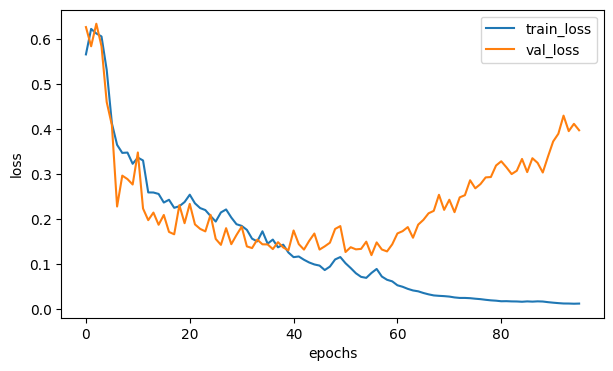


Epoch 097  |  Loss T:0.0115 V:0.4122  |  Accuracy T:0.9951, V:0.9441

Epoch 098  |  Loss T:0.0118 V:0.3851  |  Accuracy T:0.9950, V:0.9435

Epoch 099  |  Loss T:0.0118 V:0.3579  |  Accuracy T:0.9949, V:0.9459

Epoch 100  |  Loss T:0.0115 V:0.3806  |  Accuracy T:0.9951, V:0.9436

Epoch 101  |  Loss T:0.0108 V:0.4144  |  Accuracy T:0.9954, V:0.9441

Epoch 102  |  Loss T:0.0106 V:0.4113  |  Accuracy T:0.9955, V:0.9438

Epoch 103  |  Loss T:0.0107 V:0.4209  |  Accuracy T:0.9954, V:0.9440

Epoch 104  |  Loss T:0.0103 V:0.4322  |  Accuracy T:0.9956, V:0.9437

Epoch 105  |  Loss T:0.0098 V:0.4607  |  Accuracy T:0.9958, V:0.9437

Epoch 106  |  Loss T:0.0098 V:0.4205  |  Accuracy T:0.9958, V:0.9436

Epoch 107  |  Loss T:0.0108 V:0.4235  |  Accuracy T:0.9954, V:0.9434

Epoch 108  |  Loss T:0.0104 V:0.4351  |  Accuracy T:0.9956, V:0.9439

Epoch 109  |  Loss T:0.0102 V:0.4356  |  Accuracy T:0.9957, V:0.9430

Epoch 110  |  Loss T:0.0097 V:0.4202  |  Accuracy T:0.9959, V:0.9443

Epoch 111  |  Loss 

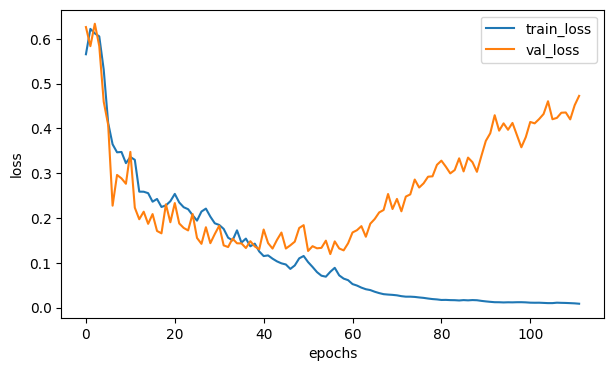


Epoch 113  |  Loss T:0.0083 V:0.5081  |  Accuracy T:0.9965, V:0.9432

Epoch 114  |  Loss T:0.0084 V:0.4787  |  Accuracy T:0.9964, V:0.9445

Epoch 115  |  Loss T:0.0082 V:0.5091  |  Accuracy T:0.9965, V:0.9436

Epoch 116  |  Loss T:0.0082 V:0.5078  |  Accuracy T:0.9965, V:0.9429

Epoch 117  |  Loss T:0.0081 V:0.5306  |  Accuracy T:0.9965, V:0.9435

Epoch 118  |  Loss T:0.0081 V:0.4887  |  Accuracy T:0.9966, V:0.9441

Epoch 119  |  Loss T:0.0081 V:0.5299  |  Accuracy T:0.9966, V:0.9427

Epoch 120  |  Loss T:0.0090 V:0.4515  |  Accuracy T:0.9961, V:0.9430

Epoch 121  |  Loss T:0.0095 V:0.4695  |  Accuracy T:0.9959, V:0.9435

Epoch 122  |  Loss T:0.0093 V:0.4358  |  Accuracy T:0.9961, V:0.9441

Epoch 123  |  Loss T:0.0087 V:0.4774  |  Accuracy T:0.9963, V:0.9430

Epoch 124  |  Loss T:0.0083 V:0.5056  |  Accuracy T:0.9965, V:0.9425

Epoch 125  |  Loss T:0.0081 V:0.4666  |  Accuracy T:0.9966, V:0.9439

Epoch 126  |  Loss T:0.0077 V:0.4989  |  Accuracy T:0.9967, V:0.9453

Epoch 127  |  Loss 

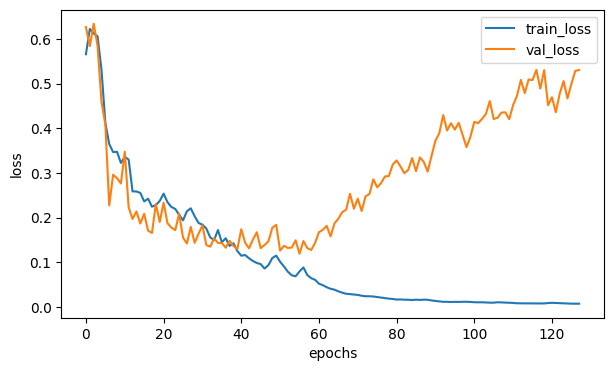

In [193]:
model = SegNet().to(DEVICE)

bce_mean = nn.BCEWithLogitsLoss(reduction='mean')

history = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=model, 
    epochs=128, 
    batch_size=16, 
    criterion=bce_mean,
    optimizer=torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

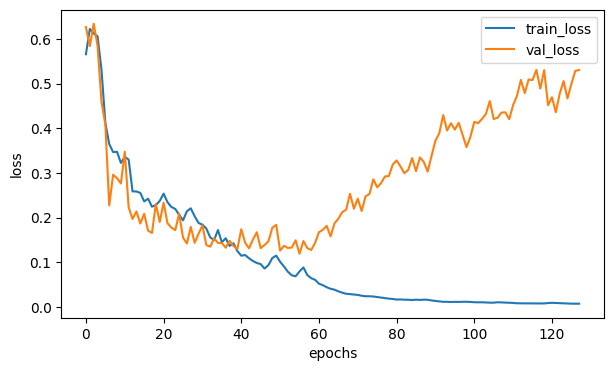

In [194]:
plot_epoch_loss(history)

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [195]:
checkpoint = torch.load("best_model.pth", map_location=DEVICE)

model = SegNet().to(DEVICE)
model.load_state_dict(checkpoint["model_state"])

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\646830043.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_model.pth", map_locatio

<All keys matched successfully>

In [196]:
test_dataset = to_tensor_dataset(X[ts], Y[ts])
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)

In [197]:
def test(model, val_loader, criterion):
    iou_score.reset()
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.no_grad():
            logits = model(inputs)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += inputs.numel()
        processed_batches += 1

        iou_score.update(preds, labels)

    avg_loss = running_loss / processed_batches
    avg_acc = running_corrects.double() / processed_pixels
    return avg_loss, avg_acc

In [198]:
test_loss, test_acc = test(model, test_loader, criterion=bce_mean)
print(f'Test loss: {test_loss}, test accuracy: {test_acc}')

print(f'Test IoU: {iou_score.compute()}')


Test loss: 0.1633962094783783, test accuracy: 0.31240386962890626
Test IoU: 0.839164674282074


# Задания: Мир других лососов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [228]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    probs = F.sigmoid(logits)
    preds = (probs > threshold).to(int)

    tp = ((preds == 1) & (labels == 1)).sum() / labels.size(1)
    fp = ((preds == 1) & (labels == 0)).sum() / labels.size(1)
    fn = ((preds == 0) & (labels == 1)).sum() / labels.size(1)

    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    return score

Проверим на корректность функцию dice_score:

In [200]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(DEVICE)
dice(dummpy_sample['logits'].sigmoid() > 0.5, dummpy_sample['labels'].to(int))

c:\Users\efimplotnikov\Projects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.6667, device='cuda:0')

In [201]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(DEVICE)

'''

"\nесли вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():\n\nfrom torchmetrics.classification import Dice\n\ndice = Dice(average='micro').to(DEVICE)\n\n"

In [202]:
dice_torch = dice(dummpy_sample['logits'].sigmoid() > 0.5, dummpy_sample['labels'].to(int))
dice_custom = dice_score(dummpy_sample['logits'], dummpy_sample['labels'].to(int))
print(dice_torch, dice_custom)
assert dice_torch == dice_custom

tensor(0.6667, device='cuda:0') tensor(0.6667, device='cuda:0')


Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

In [236]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    logits = torch.clamp(logits, -20, 20) # HACK: sigmoid is oversaturated otherwise
    probs = F.sigmoid(logits)
    probs = probs.flatten(1)
    labels = labels.flatten(1)

    tp = (probs * labels).sum(dim=1)
    fp = (probs * (1 - labels)).sum(dim=1)
    fn = ((1 - probs) * labels).sum(dim=1)

    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    return 1 - score.mean()

Проверка на корректность:

In [204]:
# проверьте, что у вас установлена библиотека
#!pip install segmentation-models-pytorch

In [205]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [206]:
loss_torch = dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int))
loss_custom = dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])
print(loss_torch, loss_custom)
assert loss_torch == loss_custom

tensor(0.5756, device='cuda:0') tensor(0.5756, device='cuda:0')


### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [217]:
def focal_loss(y_pred, y_real, eps = 1e-8, gamma = 2, reduction='mean'):
    prob = torch.sigmoid(y_pred)
    p_t = prob * y_real + (1 - prob) * (1 - y_real)
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real, reduction="none")
    modulating_factor = (1.0 - p_t) ** gamma
    loss = modulating_factor * bce

    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    
    return loss

Проверка корректности функции:

In [208]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='mean')

tensor(0.2260, device='cuda:0')

In [209]:
torch_focal = sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='mean')
custom_focal = focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], gamma=2.0, reduction='mean')
print(torch_focal, "\n", custom_focal)
assert torch_focal == custom_focal

tensor(0.2260, device='cuda:0') 
 tensor(0.2260, device='cuda:0')


## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [210]:
# TODO

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [234]:
# Если при обучении падает по out of memory, то память сама не чистится без перезапуска ядра
# так что тут ручная зачистка для повторных запусков
import gc

if 'model' in globals(): 
    del model
if 'dice_model' in globals():
    del dice_model
if 'focal_model' in globals():
    del focal_model
gc.collect()
    
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

epoch:   0%|          | 0/128 [00:00<?, ?it/s]

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.17432594299316406
logits mean/std, probs mean: 0.33668965101242065 0.40526047348976135 0.5792405605316162
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4126777648925781
logits mean/std, probs mean: 0.26443830132484436 1.0362271070480347 0.5332930684089661
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.25015830993652344
logits mean/std, probs mean: 0.3503172993659973 1.249298334121704 0.5413979291915894
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3381767272949219
logits mean/std, probs mean: 0.5943871736526489 1.1755589246749878 0.5964266657829285
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4151496887207031
logits mean/std, probs mean: 0.7102841734886169 1.0969784259796143 0.6268668174743652
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.24020767211914062
logits mean/std, probs mean: 0.8249508142471313 1.0369057655334473 0.6551575660705566
labels dtype/min/max/un

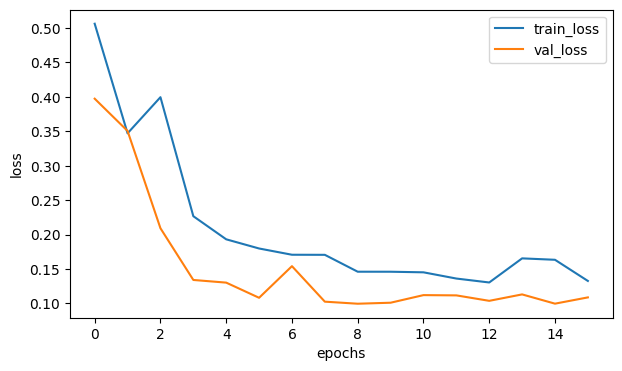

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.40619850158691406
logits mean/std, probs mean: 1576.31298828125 3424.38818359375 0.3963012397289276
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.35137367248535156
logits mean/std, probs mean: 1844.718505859375 4596.3271484375 0.3355182409286499
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.36163902282714844
logits mean/std, probs mean: 2173.60400390625 5084.1611328125 0.36497581005096436
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2459869384765625
logits mean/std, probs mean: 2103.01904296875 7178.59521484375 0.2104732096195221
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.39122962951660156
logits mean/std, probs mean: 5063.609375 13260.0888671875 0.37818530201911926
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.27455902099609375
logits mean/std, probs mean: 3097.429443359375 10154.232421875 0.3507777452468872
labels dtype/min/max/unique_ratio: torch.float32 0.

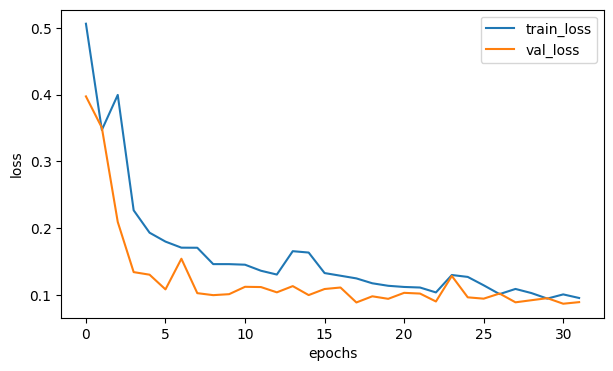

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4864006042480469
logits mean/std, probs mean: 4279.9267578125 15721.8896484375 0.4441225826740265
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2809734344482422
logits mean/std, probs mean: 5360.2021484375 16275.9423828125 0.2718474268913269
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.32966041564941406
logits mean/std, probs mean: 5781.2158203125 21576.111328125 0.3468344211578369
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3137836456298828
logits mean/std, probs mean: 3556.242431640625 12239.609375 0.29424530267715454
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2535858154296875
logits mean/std, probs mean: 2896.642578125 10017.623046875 0.2503502666950226
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4111480712890625
logits mean/std, probs mean: 3354.9931640625 8685.4208984375 0.3859177231788635
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.387

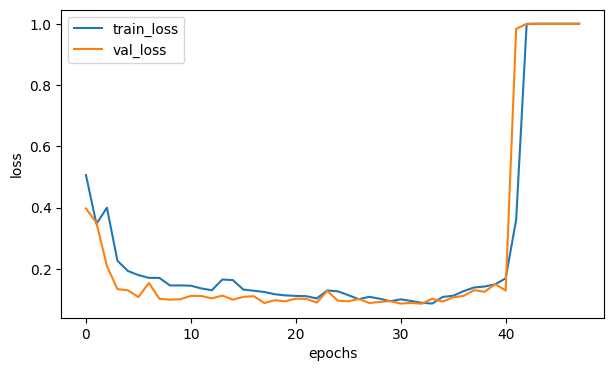

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.25835227966308594
logits mean/std, probs mean: -619561728.0 402128064.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2535419464111328
logits mean/std, probs mean: -568087616.0 357084640.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.32938575744628906
logits mean/std, probs mean: -616993536.0 391941568.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.30036163330078125
logits mean/std, probs mean: -567144128.0 349998208.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3921375274658203
logits mean/std, probs mean: -674961472.0 424843424.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3475666046142578
logits mean/std, probs mean: -592064000.0 378494176.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3600139617919922
logits mean/std, probs mean: -618308096.0 390198144.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.

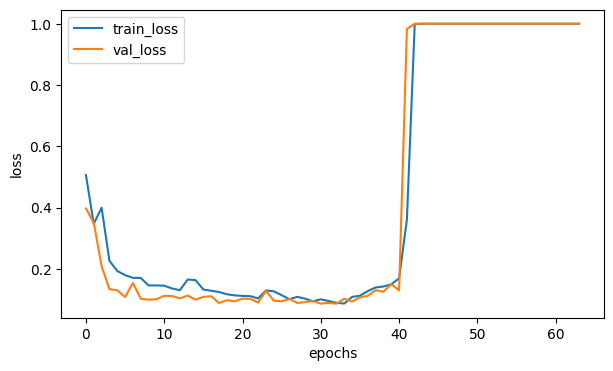

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.19125938415527344
logits mean/std, probs mean: -571007744.0 338711552.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.34354400634765625
logits mean/std, probs mean: -530409376.0 331391840.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4505634307861328
logits mean/std, probs mean: -617346496.0 395312320.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.30536460876464844
logits mean/std, probs mean: -547824192.0 322889760.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4170074462890625
logits mean/std, probs mean: -604829184.0 381529632.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3047447204589844
logits mean/std, probs mean: -529637536.0 336387584.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.15607261657714844
logits mean/std, probs mean: -526481760.0 304459744.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0

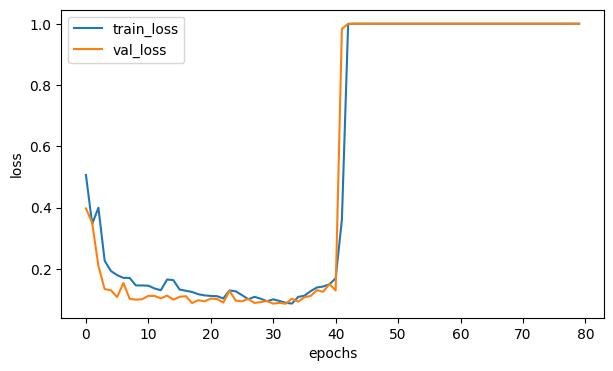

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3686256408691406
logits mean/std, probs mean: -534326240.0 320285984.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.20607757568359375
logits mean/std, probs mean: -522183328.0 318577888.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.39789772033691406
logits mean/std, probs mean: -526155296.0 339222720.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.18097686767578125
logits mean/std, probs mean: -478310592.0 291441664.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.34653282165527344
logits mean/std, probs mean: -525205056.0 318379808.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.22749900817871094
logits mean/std, probs mean: -458850848.0 294497760.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2760124206542969
logits mean/std, probs mean: -515443136.0 305642368.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 

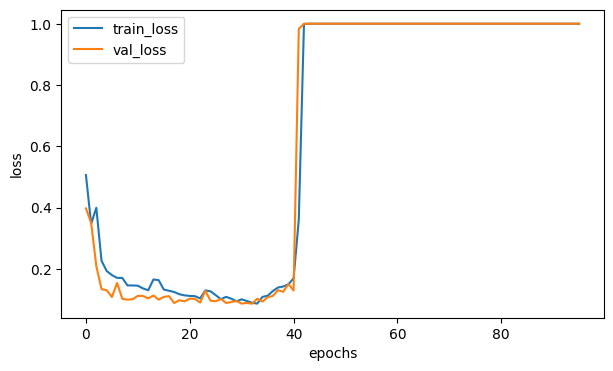

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2601203918457031
logits mean/std, probs mean: -478071200.0 295902720.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3287162780761719
logits mean/std, probs mean: -452086784.0 278503136.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.25553131103515625
logits mean/std, probs mean: -439576128.0 268828256.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.22599411010742188
logits mean/std, probs mean: -438791360.0 266028032.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3209190368652344
logits mean/std, probs mean: -486936960.0 288122880.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.36768150329589844
logits mean/std, probs mean: -490139648.0 314085696.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.32407188415527344
logits mean/std, probs mean: -505485376.0 314449312.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0

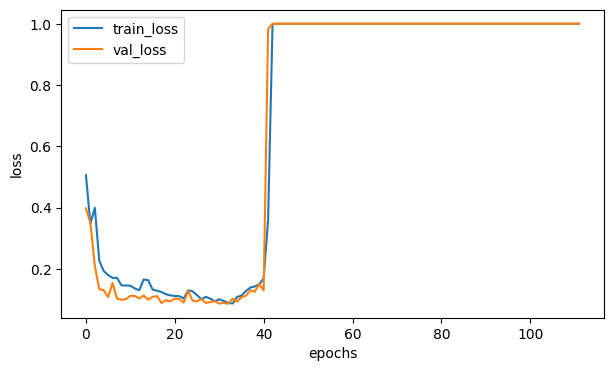

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.27485084533691406
logits mean/std, probs mean: -464640000.0 287680512.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3387718200683594
logits mean/std, probs mean: -439439968.0 271806688.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4427661895751953
logits mean/std, probs mean: -487111328.0 300402240.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.32419586181640625
logits mean/std, probs mean: -433434880.0 269159296.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.15717315673828125
logits mean/std, probs mean: -416603456.0 269375904.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.30495452880859375
logits mean/std, probs mean: -423270496.0 264744752.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3488349914550781
logits mean/std, probs mean: -511117792.0 320325728.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0

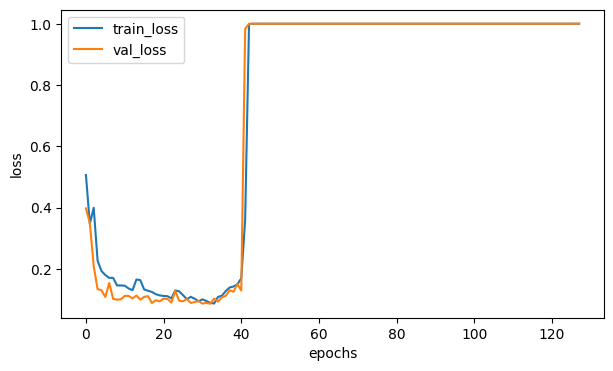

In [237]:
dice_model = SegNet().to(DEVICE)

history_dice = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=dice_model, 
    model_name='dice_model',
    epochs=128, 
    batch_size=8, 
    criterion=dice_loss,
    optimizer=torch.optim.AdamW(dice_model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

In [238]:
checkpoint = torch.load("best_dice_model.pth", map_location=DEVICE)

best_dice_model = SegNet().to(DEVICE)
best_dice_model.load_state_dict(checkpoint["model_state"])

test_loss, test_acc = test(best_dice_model, test_loader, criterion=dice_loss)
approx_time_per_epoch = (15*60 + 30) / 128
print(f'Best epoch: {checkpoint["epoch"]} (approx. elapsed time: {approx_time_per_epoch * checkpoint["epoch"]} sec.)')
print(f'Best dice model | Test loss: {test_loss}, test accuracy: {test_acc}')
print(f'Best dice model | Test IoU: {iou_score.compute()}')

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\64079397.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_dice_model.pth", map_loc

Best epoch: 32 (approx. elapsed time: 232.5 sec.)
Best dice model | Test loss: 0.09440344572067261, test accuracy: 0.31219151814778645
Best dice model | Test IoU: 0.8404562473297119


epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.1187 V:0.1696  |  Accuracy T:0.7937, V:0.6721

Epoch 002  |  Loss T:1.1679 V:0.1366  |  Accuracy T:0.6719, V:0.6800

Epoch 003  |  Loss T:0.1259 V:0.1072  |  Accuracy T:0.7667, V:0.8191

Epoch 004  |  Loss T:0.1172 V:0.1076  |  Accuracy T:0.8093, V:0.8364

Epoch 005  |  Loss T:0.1126 V:0.1006  |  Accuracy T:0.8225, V:0.8461

Epoch 006  |  Loss T:0.1080 V:0.1004  |  Accuracy T:0.8280, V:0.8490

Epoch 007  |  Loss T:0.1079 V:0.0916  |  Accuracy T:0.8315, V:0.8603

Epoch 008  |  Loss T:0.0979 V:0.0887  |  Accuracy T:0.8461, V:0.8622

Epoch 009  |  Loss T:0.0940 V:0.0814  |  Accuracy T:0.8535, V:0.8777

Epoch 010  |  Loss T:0.0796 V:0.0762  |  Accuracy T:0.8851, V:0.8942

Epoch 011  |  Loss T:0.0736 V:0.0945  |  Accuracy T:0.8969, V:0.8516

Epoch 012  |  Loss T:0.0913 V:0.0709  |  Accuracy T:0.8602, V:0.9039

Epoch 013  |  Loss T:0.0761 V:0.0613  |  Accuracy T:0.8901, V:0.9070

Epoch 014  |  Loss T:0.0718 V:0.0596  |  Accuracy T:0.8947, V:0.9075

Epoch 015  |  Loss 

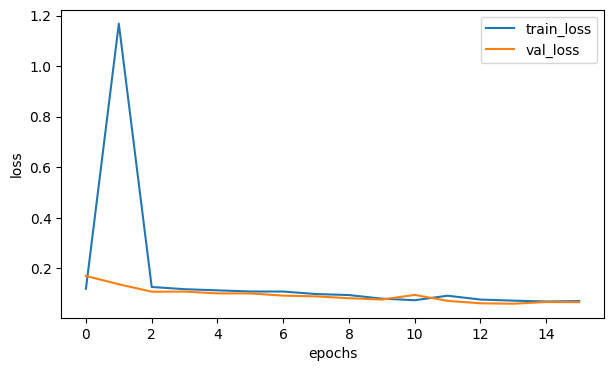


Epoch 017  |  Loss T:0.0696 V:0.0620  |  Accuracy T:0.8952, V:0.9056

Epoch 018  |  Loss T:0.0674 V:0.0645  |  Accuracy T:0.9020, V:0.8983

Epoch 019  |  Loss T:0.0704 V:0.0592  |  Accuracy T:0.8964, V:0.9075

Epoch 020  |  Loss T:0.0724 V:0.0580  |  Accuracy T:0.8883, V:0.9115

Epoch 021  |  Loss T:0.0647 V:0.0598  |  Accuracy T:0.9024, V:0.9082

Epoch 022  |  Loss T:0.0662 V:0.0700  |  Accuracy T:0.9000, V:0.8934

Epoch 023  |  Loss T:0.0704 V:0.0680  |  Accuracy T:0.8970, V:0.9127

Epoch 024  |  Loss T:0.0738 V:0.0617  |  Accuracy T:0.8963, V:0.9059

Epoch 025  |  Loss T:0.0685 V:0.0604  |  Accuracy T:0.9002, V:0.9121

Epoch 026  |  Loss T:0.0656 V:0.0576  |  Accuracy T:0.9050, V:0.9112

Epoch 027  |  Loss T:0.0706 V:0.0576  |  Accuracy T:0.8938, V:0.9128

Epoch 028  |  Loss T:0.0664 V:0.0598  |  Accuracy T:0.9031, V:0.9067

Epoch 029  |  Loss T:0.0653 V:0.0607  |  Accuracy T:0.9038, V:0.9066

Epoch 030  |  Loss T:0.0666 V:0.0599  |  Accuracy T:0.8990, V:0.9136

Epoch 031  |  Loss 

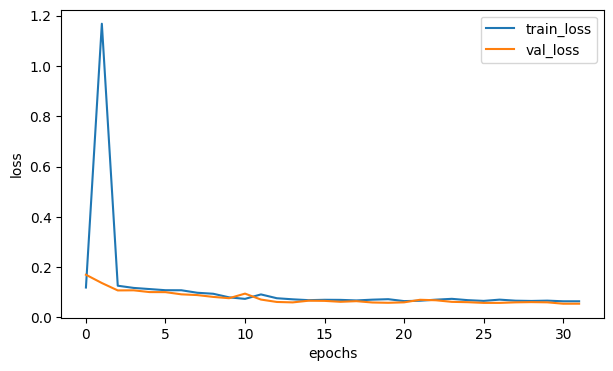


Epoch 033  |  Loss T:0.0640 V:0.0538  |  Accuracy T:0.9056, V:0.9175

Epoch 034  |  Loss T:0.0600 V:0.0504  |  Accuracy T:0.9124, V:0.9244

Epoch 035  |  Loss T:0.0598 V:0.0575  |  Accuracy T:0.9125, V:0.9105

Epoch 036  |  Loss T:0.0601 V:0.0514  |  Accuracy T:0.9126, V:0.9261

Epoch 037  |  Loss T:0.0571 V:0.0537  |  Accuracy T:0.9184, V:0.9189

Epoch 038  |  Loss T:0.0555 V:0.0593  |  Accuracy T:0.9226, V:0.9115

Epoch 039  |  Loss T:0.0556 V:0.0557  |  Accuracy T:0.9179, V:0.9248

Epoch 040  |  Loss T:0.0557 V:0.0544  |  Accuracy T:0.9191, V:0.9171

Epoch 041  |  Loss T:0.0525 V:0.0565  |  Accuracy T:0.9236, V:0.9196

Epoch 042  |  Loss T:0.0575 V:0.0535  |  Accuracy T:0.9163, V:0.9210

Epoch 043  |  Loss T:0.0556 V:0.0463  |  Accuracy T:0.9194, V:0.9280

Epoch 044  |  Loss T:0.0574 V:0.0542  |  Accuracy T:0.9134, V:0.9195

Epoch 045  |  Loss T:0.0565 V:0.0513  |  Accuracy T:0.9138, V:0.9185

Epoch 046  |  Loss T:0.0523 V:0.0567  |  Accuracy T:0.9182, V:0.9175

Epoch 047  |  Loss 

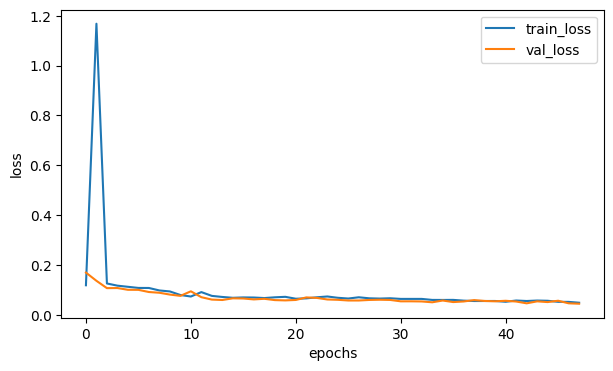


Epoch 049  |  Loss T:0.0488 V:0.0577  |  Accuracy T:0.9280, V:0.9121

Epoch 050  |  Loss T:0.0536 V:0.0551  |  Accuracy T:0.9190, V:0.9159

Epoch 051  |  Loss T:0.0504 V:0.0528  |  Accuracy T:0.9226, V:0.9142

Epoch 052  |  Loss T:0.0482 V:0.0427  |  Accuracy T:0.9255, V:0.9293

Epoch 053  |  Loss T:0.0488 V:0.0769  |  Accuracy T:0.9212, V:0.8630

Epoch 054  |  Loss T:0.0570 V:0.0569  |  Accuracy T:0.9116, V:0.9155

Epoch 055  |  Loss T:0.0473 V:0.0438  |  Accuracy T:0.9256, V:0.9236

Epoch 056  |  Loss T:0.0462 V:0.0473  |  Accuracy T:0.9288, V:0.9206

Epoch 057  |  Loss T:0.0450 V:0.0470  |  Accuracy T:0.9315, V:0.9270

Epoch 058  |  Loss T:0.0399 V:0.0461  |  Accuracy T:0.9378, V:0.9250

Epoch 059  |  Loss T:0.0379 V:0.0466  |  Accuracy T:0.9412, V:0.9186

Epoch 060  |  Loss T:0.0372 V:0.0497  |  Accuracy T:0.9415, V:0.9116

Epoch 061  |  Loss T:0.0388 V:0.0487  |  Accuracy T:0.9372, V:0.9249

Epoch 062  |  Loss T:0.0431 V:0.0453  |  Accuracy T:0.9283, V:0.9252

Epoch 063  |  Loss 

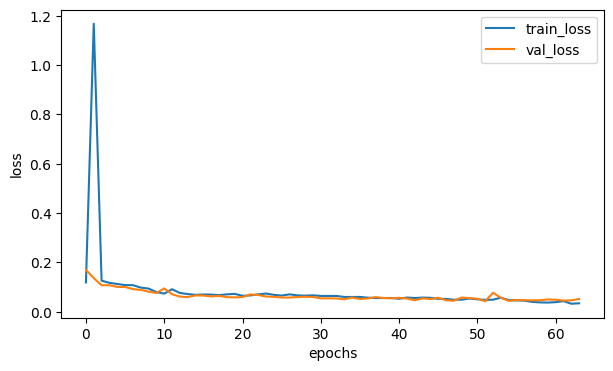


Epoch 065  |  Loss T:0.0442 V:0.0798  |  Accuracy T:0.9331, V:0.9050

Epoch 066  |  Loss T:0.0462 V:0.0494  |  Accuracy T:0.9321, V:0.9188

Epoch 067  |  Loss T:0.0453 V:0.0418  |  Accuracy T:0.9294, V:0.9312

Epoch 068  |  Loss T:0.0335 V:0.0391  |  Accuracy T:0.9477, V:0.9360

Epoch 069  |  Loss T:0.0292 V:0.0565  |  Accuracy T:0.9537, V:0.9229

Epoch 070  |  Loss T:0.0279 V:0.0438  |  Accuracy T:0.9554, V:0.9340

Epoch 071  |  Loss T:0.0328 V:0.0467  |  Accuracy T:0.9510, V:0.9200

Epoch 072  |  Loss T:0.0323 V:0.0383  |  Accuracy T:0.9477, V:0.9427

Epoch 073  |  Loss T:0.0324 V:0.0408  |  Accuracy T:0.9473, V:0.9277

Epoch 074  |  Loss T:0.0311 V:0.0474  |  Accuracy T:0.9502, V:0.9248

Epoch 075  |  Loss T:0.0271 V:0.0517  |  Accuracy T:0.9568, V:0.9166

Epoch 076  |  Loss T:0.0387 V:0.0406  |  Accuracy T:0.9397, V:0.9381

Epoch 077  |  Loss T:0.0364 V:0.0619  |  Accuracy T:0.9413, V:0.9303

Epoch 078  |  Loss T:0.0437 V:0.0560  |  Accuracy T:0.9374, V:0.9108

Epoch 079  |  Loss 

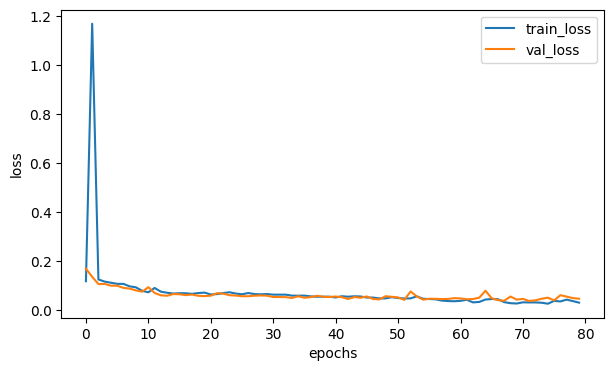


Epoch 081  |  Loss T:0.0268 V:0.0425  |  Accuracy T:0.9583, V:0.9365

Epoch 082  |  Loss T:0.0272 V:0.0651  |  Accuracy T:0.9575, V:0.9123

Epoch 083  |  Loss T:0.0253 V:0.0465  |  Accuracy T:0.9603, V:0.9376

Epoch 084  |  Loss T:0.0241 V:0.0458  |  Accuracy T:0.9608, V:0.9294

Epoch 085  |  Loss T:0.0265 V:0.0475  |  Accuracy T:0.9600, V:0.9386

Epoch 086  |  Loss T:0.0240 V:0.0403  |  Accuracy T:0.9615, V:0.9430

Epoch 087  |  Loss T:0.0206 V:0.0496  |  Accuracy T:0.9663, V:0.9363

Epoch 088  |  Loss T:0.0187 V:0.0543  |  Accuracy T:0.9693, V:0.9378

Epoch 089  |  Loss T:0.0171 V:0.0580  |  Accuracy T:0.9717, V:0.9423

Epoch 090  |  Loss T:0.0201 V:0.0463  |  Accuracy T:0.9692, V:0.9351

Epoch 091  |  Loss T:0.0293 V:0.0439  |  Accuracy T:0.9536, V:0.9323

Epoch 092  |  Loss T:0.0296 V:0.0400  |  Accuracy T:0.9522, V:0.9401

Epoch 093  |  Loss T:0.0451 V:0.0520  |  Accuracy T:0.9361, V:0.9267

Epoch 094  |  Loss T:0.0353 V:0.0490  |  Accuracy T:0.9449, V:0.9200

Epoch 095  |  Loss 

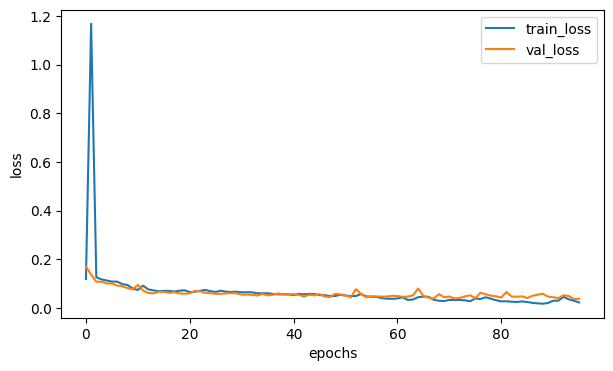


Epoch 097  |  Loss T:0.0314 V:0.0467  |  Accuracy T:0.9514, V:0.9362

Epoch 098  |  Loss T:0.0286 V:0.0450  |  Accuracy T:0.9524, V:0.9330

Epoch 099  |  Loss T:0.0229 V:0.0506  |  Accuracy T:0.9637, V:0.9379

Epoch 100  |  Loss T:0.0182 V:0.0501  |  Accuracy T:0.9698, V:0.9425

Epoch 101  |  Loss T:0.0154 V:0.0493  |  Accuracy T:0.9746, V:0.9446

Epoch 102  |  Loss T:0.0148 V:0.0521  |  Accuracy T:0.9763, V:0.9436

Epoch 103  |  Loss T:0.0139 V:0.0534  |  Accuracy T:0.9776, V:0.9438

Epoch 104  |  Loss T:0.0121 V:0.0677  |  Accuracy T:0.9806, V:0.9395

Epoch 105  |  Loss T:0.0108 V:0.0696  |  Accuracy T:0.9828, V:0.9401

Epoch 106  |  Loss T:0.0094 V:0.0669  |  Accuracy T:0.9850, V:0.9405

Epoch 107  |  Loss T:0.0089 V:0.0746  |  Accuracy T:0.9859, V:0.9380

Epoch 108  |  Loss T:0.0083 V:0.0760  |  Accuracy T:0.9869, V:0.9356

Epoch 109  |  Loss T:0.0079 V:0.0784  |  Accuracy T:0.9875, V:0.9411

Epoch 110  |  Loss T:0.0070 V:0.0916  |  Accuracy T:0.9887, V:0.9401

Epoch 111  |  Loss 

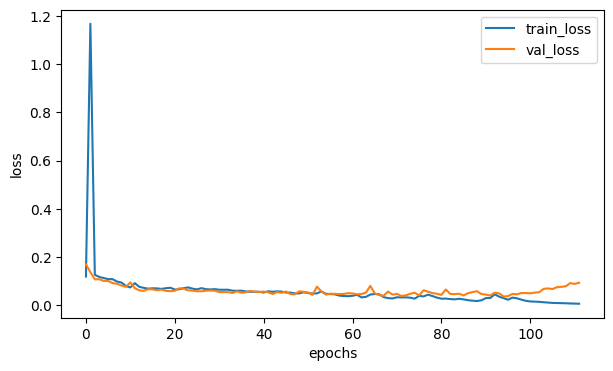


Epoch 113  |  Loss T:0.0080 V:0.0805  |  Accuracy T:0.9880, V:0.9366

Epoch 114  |  Loss T:0.0187 V:0.0588  |  Accuracy T:0.9727, V:0.9365

Epoch 115  |  Loss T:0.0193 V:0.0447  |  Accuracy T:0.9693, V:0.9428

Epoch 116  |  Loss T:0.0125 V:0.0454  |  Accuracy T:0.9808, V:0.9474

Epoch 117  |  Loss T:0.0098 V:0.0575  |  Accuracy T:0.9844, V:0.9435

Epoch 118  |  Loss T:0.0078 V:0.0806  |  Accuracy T:0.9878, V:0.9362

Epoch 119  |  Loss T:0.0065 V:0.0795  |  Accuracy T:0.9896, V:0.9409

Epoch 120  |  Loss T:0.0061 V:0.0746  |  Accuracy T:0.9901, V:0.9438

Epoch 121  |  Loss T:0.0056 V:0.0939  |  Accuracy T:0.9911, V:0.9451

Epoch 122  |  Loss T:0.0050 V:0.0933  |  Accuracy T:0.9921, V:0.9443

Epoch 123  |  Loss T:0.0045 V:0.0998  |  Accuracy T:0.9928, V:0.9441

Epoch 124  |  Loss T:0.0041 V:0.1072  |  Accuracy T:0.9935, V:0.9449

Epoch 125  |  Loss T:0.0040 V:0.1113  |  Accuracy T:0.9937, V:0.9425

Epoch 126  |  Loss T:0.0040 V:0.1156  |  Accuracy T:0.9935, V:0.9442

Epoch 127  |  Loss 

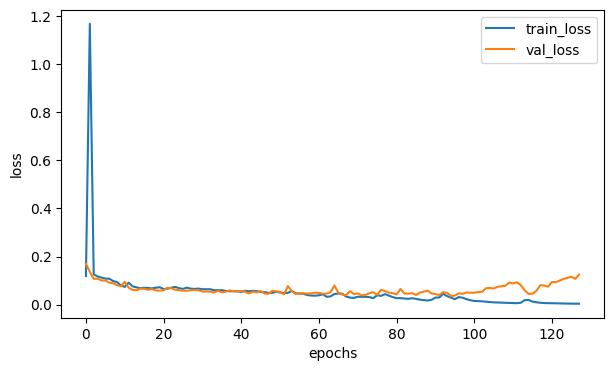

In [221]:
focal_model = SegNet().to(DEVICE)

history_focal = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=focal_model, 
    model_name='focal_model',
    epochs=128, 
    batch_size=8, 
    criterion=focal_loss,
    optimizer=torch.optim.AdamW(focal_model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss 
)

In [223]:
checkpoint = torch.load("best_focal_model.pth", map_location=DEVICE)

best_focal_model = SegNet().to(DEVICE)
best_focal_model.load_state_dict(checkpoint["model_state"])

test_loss, test_acc = test(best_focal_model, test_loader, criterion=focal_loss)
approx_time_per_epoch = (15*60 + 30) / 128
print(f'Best epoch: {checkpoint["epoch"]} (approx. elapsed time: {approx_time_per_epoch * checkpoint["epoch"]} sec.)')
print(f'Best focal model | Test loss: {test_loss}, test accuracy: {test_acc}')
print(f'Best focal model | Test IoU: {iou_score.compute()}')

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23792\2373653512.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_focal_model.pth", map_

Best epoch: 94 (approx. elapsed time: 682.96875 sec.)
Best focal model | Test loss: 0.0645749643445015, test accuracy: 0.30817413330078125
Best focal model | Test IoU: 0.8067905306816101


### Ответы

---

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

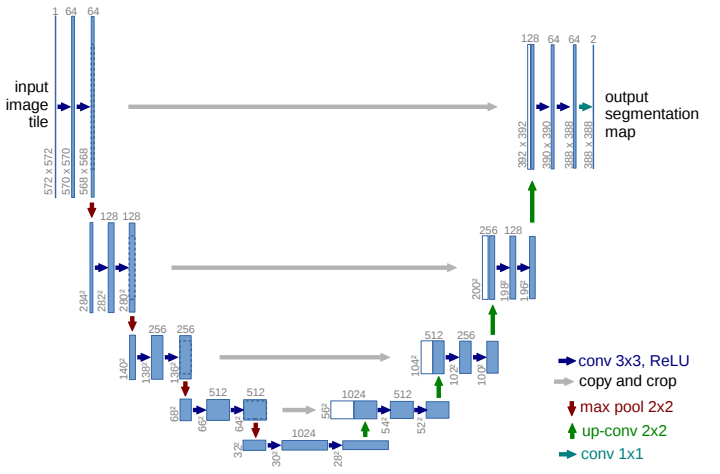

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()

        # TODO

    def forward(self, x):
        #  TODO

        return output

In [ ]:
unet_model = UNet().to(DEVICE)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.

